In [1]:
!pip install datasets librosa torchutils --quiet

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torchaudio
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer

In [22]:
train_dataset = load_dataset("openslr/librispeech_asr", "clean", split="train.100", streaming=True)
val_dataset = load_dataset("openslr/librispeech_asr", "clean", split="validation", streaming=True)

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

In [4]:
tokenizer = AutoTokenizer.from_pretrained("openai/whisper-tiny")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [5]:
sample = next(iter(train_dataset))
sample

{'file': '/home/albert/.cache/huggingface/datasets/downloads/extracted/bc0d9a6ef85c2d487c9c6efbc91f8892df927c69d3f80545a668cc058d5f677e/374-180298-0000.flac',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7bacaf1c1880>,
 'text': 'CHAPTER SIXTEEN I MIGHT HAVE TOLD YOU OF THE BEGINNING OF THIS LIAISON IN A FEW LINES BUT I WANTED YOU TO SEE EVERY STEP BY WHICH WE CAME I TO AGREE TO WHATEVER MARGUERITE WISHED',
 'speaker_id': 374,
 'chapter_id': 180298,
 'id': '374-180298-0000'}

torch.Size([80, 1454])


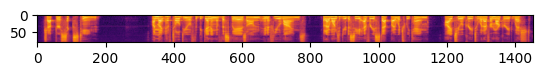

In [6]:
waveform = torch.tensor(sample['audio']['array'],dtype=torch.float32)
waveform.unsqueeze(0).shape
mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=16000,
    n_fft=400,
    hop_length=160,
    win_length=400,
    n_mels=80
)
out = mel_transform(waveform)
out = torch.log(out + 1e-9)
print(out.shape)


plt.imshow(out, cmap='inferno')
plt.show()


In [7]:
def transform_to_mel(waveform):
  mel = mel_transform(waveform)
  mel = torch.log(mel + 1e-9)
  return mel

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def collate_fn(batch):
  mels = []
  texts = []
  tokens = []
  for sample in batch:
    waveform = torch.tensor(sample['audio']['array'],dtype=torch.float32)
    # (T,) -> (1,T)
    waveform = waveform.unsqueeze(0)
    mel = transform_to_mel(waveform)
    mel = mel.squeeze(0).transpose(0,1)
    # shape: (time, n_mels)
    mels.append(mel)
    texts.append(sample["text"])
    token = tokenizer.encode(sample['text'])
    tokens.append(torch.tensor(token))

  lengths = torch.tensor([m.shape[0] for m in mels])
  mel = pad_sequence(
        mels,
        batch_first=True,
    )
  padded_tokens = pad_sequence(
        tokens,
        batch_first=True,
        padding_value=tokenizer.pad_token_id
    )

  return {
        "mel": mel.to(device),
        "lengths": lengths.to(device),
        "text": texts,
        "tokens": padded_tokens.to(device)
    }

In [23]:
train_dl = DataLoader(
    train_dataset,
    batch_size=16,
    collate_fn=collate_fn
)
valid_dl = DataLoader(
    val_dataset,
    batch_size=16,
    collate_fn=collate_fn)

In [10]:
class EncoderBlock(nn.Module):
  def __init__(self,n_head,d_model):
    super().__init__()
    self.multihead_attention = nn.MultiheadAttention(d_model,n_head,batch_first=True)
    self.layernorm1 = nn.LayerNorm(d_model)
    self.mlp = nn.Sequential(
        nn.Linear(d_model,d_model*4),
        nn.GELU(),
        nn.Linear(d_model*4,d_model)
    )
    self.layernorm2 = nn.LayerNorm(d_model)

  def forward(self,x):
    x = x + self.multihead_attention(x,x,x)[0]
    x = self.layernorm1(x)
    x = x + self.mlp(x)
    x = self.layernorm2(x)
    return x


In [11]:
class DecoderBlock(nn.Module):
  def __init__(self,n_head,d_model,dropout=0.1):
    super().__init__()
    self.self_attn = nn.MultiheadAttention(d_model, n_head, batch_first=True)
    self.cross_attn = nn.MultiheadAttention(d_model, n_head, batch_first=True)

    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.norm3 = nn.LayerNorm(d_model)

    self.ffn = nn.Sequential(
        nn.Linear(d_model, 4*d_model),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(4*d_model, d_model)
    )
    self.dropout = nn.Dropout(dropout)

  def forward(self,x,encoder_output):
    """
        Args:
            x: Target tokens embeddings (B, seq_len_tgt, d_model)
            encoder_output: Encoder representations (B, seq_len_src, d_model)
        Returns:
            x: Decoder representations (B, seq_len_tgt, d_model)
    """
    seq_len_tgt = x.size(1)

    mask = torch.triu(torch.ones((seq_len_tgt, seq_len_tgt), device=x.device), diagonal=1).bool()

    residual = x
    x = self.norm1(x)
    x = residual + self.self_attn(x,x,x,attn_mask=mask,need_weights=False)[0]

    residual = x
    x = self.norm2(x)
    x = residual + self.cross_attn(x,encoder_output,encoder_output,need_weights=False)[0]

    residual = x
    x = self.norm3(x)
    x = residual + self.ffn(x)

    return x

In [12]:
class AudioEncoder(nn.Module):
  def __init__(self,
        n_mels=80,
        d_model=256,
        n_head=4,
        n_layer=6,
        max_len=3000):
    super().__init__()
    self.conv1 = nn.Conv1d(in_channels = n_mels,
                           out_channels = d_model,
                           kernel_size = 3)
    self.conv2 = nn.Conv1d(in_channels = d_model,
                           out_channels = d_model,
                           kernel_size = 3,padding=2)
    self.positional_embeddings = nn.Parameter(torch.randn(1, max_len, d_model))
    self.encoder_blocks = nn.ModuleList([EncoderBlock(n_head,d_model) for _ in range(n_layer)])

  def forward(self,x):
    x = x.transpose(1,2)
    x =  self.conv1(x)
    x = F.gelu(x)
    x =  self.conv2(x)
    x = F.gelu(x)
    x = x.transpose(1,2)
    x = x + self.positional_embeddings[:,:x.shape[1]]
    for block in self.encoder_blocks:
      x = block(x)
    return x


In [13]:
class Decoder(nn.Module):
  def __init__(self, vocab_size, d_model = 256, n_head = 4, n_layer = 6, max_len = 448, dropout=0.1):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, d_model)
    self.positional_embeddings = nn.Parameter(torch.randn(1, max_len, d_model))
    self.decoder_blocks = nn.ModuleList([DecoderBlock(n_head,d_model,dropout) for _ in range(n_layer)])
    self.norm = nn.LayerNorm(d_model)
    self.output = nn.Linear(d_model, vocab_size)

  def forward(self, tokens, encoder_output):
    x = self.embedding(tokens)

    x = x + self.positional_embeddings[:,:x.shape[1]]

    for block in self.decoder_blocks:
      x = block(x,encoder_output)

    x = self.norm(x)
    logits = self.output(x)
    return logits

In [14]:
class Whisper(nn.Module):
  def __init__(self, vocab_size, d_model = 256, n_head = 4, n_layer = 3, max_len = 448, dropout=0.1):
    super().__init__()
    self.encoder = AudioEncoder(n_mels=80,
        d_model=256,
        n_head=4,
        n_layer=n_layer,
        max_len=3000)
    self.decoder = Decoder(vocab_size, d_model = 256, n_head = 4, n_layer = n_layer, max_len = 448, dropout=0.1)

  def forward(self, mel, tokens):
    encoder_output = self.encoder(mel)
    logits = self.decoder(tokens, encoder_output)
    return logits

In [15]:
model = Whisper(len(tokenizer)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
num_epochs = 4

In [18]:
model.load_state_dict(torch.load('/kaggle/input/models/zephylus/whisper-weights/pytorch/default/1/model_weights.pth',weights_only=True))

<All keys matched successfully>

In [19]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    batch_count = 0

    for batch in train_dl:
        optimizer.zero_grad()

        mel = batch['mel'].to(device)
        tokens = batch['tokens'].to(device)
        decoder_input = tokens[:, :-1]
        target = tokens[:, 1:]

        logits = model(mel, decoder_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            target.reshape(-1)
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        batch_count += 1

    if batch_count > 0:
        epoch_loss = running_loss / batch_count
        print(f'Epoch: {epoch} | Average Loss: {epoch_loss:.4f}')
    else:
        print(f'Epoch: {epoch} | No batches processed.')

Epoch: 0 | Average Loss: 3.7439
Epoch: 1 | Average Loss: 3.6290
Epoch: 2 | Average Loss: 3.5354
Epoch: 3 | Average Loss: 3.4592


In [20]:
torch.save(model.state_dict(), 'model_weights.pth')

In [31]:
def generate_transcription(model, mel_features, tokenizer, max_len=448, device="cpu"):
    model.eval()
    mel_features = mel_features.to(device)

    encoder_output = model.encoder(mel_features)
    start_tokens = tokenizer.prefix_tokens # usually contains [<|startoftranscript|>, <|en|>, <|transcribe|>]
    tokens = torch.tensor([start_tokens], dtype=torch.long, device = device)

    # generate in autoregressive way
    for _ in range(max_len - len(start_tokens)):
        logits = model.decoder(tokens, encoder_output)
        next_token_logits = logits[:,-1,:]
        next_token = torch.argmax(next_token_logits, dim = -1, keepdim = True)
        tokens = torch.cat([tokens, next_token], dim = -1)

        if next_token.item() == tokenizer.eos_token_id:
            break
    decoded_text = tokenizer.decode(tokens[0], skip_special_tokens=True)
    return decoded_text

In [33]:
model.eval()
with torch.no_grad():
    for batch in valid_dl:
        mel = batch['mel'].to(device)
        true_tokens = batch['tokens']

        for i in range(mel.size(0)):
            single_mel = mel[i].unsqueeze(0)
            predicted_text = generate_transcription(
                model=model, 
                mel_features=single_mel, 
                tokenizer=tokenizer, 
                device=device
            )

            print('Index = ',i)
            print(f"Target (True): {batch['text'][i]}")
            print(f"Model Output : {predicted_text}")
        break

Index =  0
Target (True): HE WAS IN A FEVERED STATE OF MIND OWING TO THE BLIGHT HIS WIFE'S ACTION THREATENED TO CAST UPON HIS ENTIRE FUTURE
Model Output : AND THE FAMILIES OF THEIR FAMILY AND THEIR FAMILY AND THEIR FRIENDS THEIR FRIENDS AND THEIR PART OF THEIR FRIENDS THEIR FRIENDS AND THEIR FRIENDS AND THEIR FRIENDS AND THEIR FRIENDS AND THEIR FRIENDS AND THEIR FRIENDS THEIR FRIENDS AND THEIRTYS AND THEIRS THEIRS AND THEIR HADS WERE INSETTTSES OF THEIRS IN THEIRS AND THEIRUSLY THEIR FRIENCHYS THEIRDED THEIRYALTY THEIRTSORSYROATED THEIRITS THEIR HERS AND THEIRTED THEIRCREADS AND THEIRALSE THEIR OY AND THEIRTEDUCES AND THEIRS THEIRANY AND THEIRUS THRALTHERS WERE AND THEIRSELVES AND THEIRITS THEIRS THEIRUNDERY HADERS WERE THEIR FRISEN THEIRS OF THEIRUSNENTYREASED THEIRDS THEIR WERE AND THEIRDONORATUS THEIR THEIR HONS THEIRY WAS THEIRSEN'S AND THEIRS OF THEIRS THEIRRENTYALTIFERWARNOTE THEIRYS THEIRES AND THEIRUNDED THEIRSENED THEIRRE HOMB THEIRUSESTS AND THEIRALLEDGE AND THEIRATIONSTERNES